# Task 07 — Machine Learning Foundations
### Train/Test Split, Model Fit, and Linear Regression

**Dataset:** Titanic (loaded via seaborn's built-in copy)

This notebook covers:
- Part A: Train/Test Split theory + implementation
- Part B: Overfitting, Underfitting & Bias-Variance Tradeoff
- Part C: Linear Regression theory & implementation
- Part D: Practical coding session (cleaning, functions, cross-validation, learning curves)
- Bonus: Polynomial Regression comparison


In [1]:
# Environment check — confirms scikit-learn, pandas, numpy, matplotlib are installed
import sklearn, pandas, numpy, matplotlib
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)


scikit-learn: 1.8.0
pandas: 3.0.2
numpy: 2.4.4
matplotlib: 3.10.8


---
## Part A — Train/Test Split

### A1. Why split data into training and testing sets?

A model that is evaluated on the same data it was trained on will always look better than it actually is — it can memorize the training examples (including their noise) rather than learning the underlying pattern. Splitting the data lets us hold out a portion the model never sees during training, so that when we evaluate on it, the score reflects how well the model **generalizes** to new, unseen data. This solves the problem of overly optimistic performance estimates and helps detect overfitting before the model is deployed.

### A2. Typical split ratios

| Split | When it's appropriate |
|---|---|
| 70/30 | Smaller datasets, where you want a larger test set to get a statistically reliable evaluation |
| 80/20 | The most common default — a good balance between training data volume and test reliability |
| 90/10 | Very large datasets, where even 10% test data is large enough to evaluate reliably, and you want to maximize training data |

As a rule of thumb: the more data you have, the smaller a *percentage* you need to hold out, because even a small percentage of a huge dataset is a statistically sound test set.

### A3. Implementing train_test_split


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("titanic.csv")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
X_demo = df[["pclass", "age", "sibsp", "parch"]].fillna(df[["pclass","age","sibsp","parch"]].median())
y_demo = df["fare"]

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42
)

print("Train shape:", X_train_demo.shape)
print("Test shape:", X_test_demo.shape)


Train shape: (712, 4)
Test shape: (179, 4)


### A4. Why does `random_state` matter?

`train_test_split` shuffles the data before splitting it. Without fixing `random_state`, every run produces a different shuffle, and therefore a different train/test split — meaning your evaluation metrics would change slightly every time you re-run the notebook, and results wouldn't be reproducible between your own runs or between you and a collaborator. Setting `random_state` to a fixed integer (e.g. `42`) seeds the random number generator, so the same rows always end up in the same split every time the code runs. This is essential for fair comparisons between models and for others to reproduce your results.

### A5. Validation set vs. test set

- **Test set**: held out and used **only once**, at the very end, to report the final, honest performance of the finished model. It should never influence any decisions made during development.
- **Validation set**: used **during** development to tune hyperparameters and make model-selection decisions (e.g. choosing polynomial degree, regularization strength). Because you look at it repeatedly and make choices based on it, it can leak into the model selection process — which is why a separate, untouched test set is still needed for the final, unbiased evaluation.

A common split is train/validation/test (e.g. 60/20/20), or the validation set is approximated using cross-validation (see Part D).


---
## Part B — Overfitting, Underfitting & Bias-Variance Tradeoff

### B1. Definitions

- **Underfitting**: the model is too simple to capture the underlying pattern in the data. It performs poorly on *both* the training set and the test set. Example: fitting a straight line to data that is clearly curved (quadratic).
- **Overfitting**: the model is too complex and starts fitting the noise in the training data rather than the true underlying pattern. It performs very well on the training set but poorly on the test set. Example: fitting a degree-15 polynomial through 20 noisy data points — it will pass through nearly every training point but oscillate wildly between them, generalizing badly.

### B2. Bias-variance tradeoff

- **Bias** is the error introduced by approximating a real, often complex relationship with a simplified model. High bias means the model makes strong assumptions and misses relevant patterns — this is the source of underfitting.
- **Variance** is the error introduced by the model's sensitivity to small fluctuations in the training data. High variance means the model changes a lot depending on exactly which training samples it saw — this is the source of overfitting.

As model complexity increases:
- Bias tends to **decrease** (the model can represent more complex patterns)
- Variance tends to **increase** (the model becomes more sensitive to the specific training sample)

Total expected error is roughly `Bias² + Variance + Irreducible Error`. The goal is to find the complexity level that minimizes this combined error — not the complexity that minimizes training error alone.

### B3. Techniques to reduce overfitting

1. **Regularization** (L1/Lasso, L2/Ridge) — penalizes large coefficients, discouraging the model from fitting noise.
2. **Cross-validation** — gives a more reliable estimate of generalization performance and helps in choosing hyperparameters that don't just overfit to one particular split.
3. **More training data** — with more examples, it becomes harder for the model to memorize noise instead of the real pattern.
4. **Simpler models / feature selection** — reducing model complexity or the number of features directly reduces variance.
5. **Early stopping** — for iterative training methods, stopping before the model starts fitting noise in later iterations.

### B4. Training error vs. test error across model complexity

We'll fit polynomial regressions of increasing degree on a small synthetic dataset (with known noise) and plot training vs. test error to visualize the tradeoff directly.


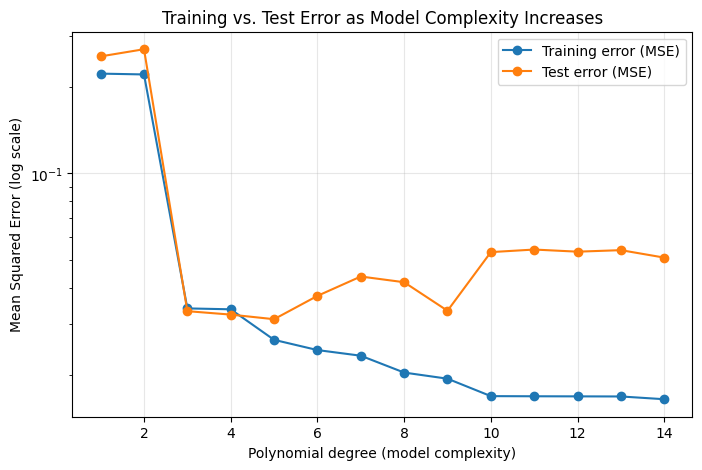

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

rng = np.random.RandomState(42)
X_syn = np.sort(rng.uniform(0, 1, 40)).reshape(-1, 1)
y_syn = np.sin(2 * np.pi * X_syn).ravel() + rng.normal(0, 0.2, size=X_syn.shape[0])

X_tr, X_te, y_tr, y_te = train_test_split(X_syn, y_syn, test_size=0.3, random_state=42)

degrees = range(1, 15)
train_errors, test_errors = [], []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_tr_poly = poly.fit_transform(X_tr)
    X_te_poly = poly.transform(X_te)

    model = LinearRegression()
    model.fit(X_tr_poly, y_tr)

    train_errors.append(mean_squared_error(y_tr, model.predict(X_tr_poly)))
    test_errors.append(mean_squared_error(y_te, model.predict(X_te_poly)))

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, marker='o', label='Training error (MSE)')
plt.plot(degrees, test_errors, marker='o', label='Test error (MSE)')
plt.yscale('log')
plt.xlabel('Polynomial degree (model complexity)')
plt.ylabel('Mean Squared Error (log scale)')
plt.title('Training vs. Test Error as Model Complexity Increases')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('bias_variance_plot.png', dpi=100, bbox_inches='tight')
plt.show()


**Reading the plot:** at low degrees (1–2), both training and test error are high — this is underfitting (high bias). As degree increases, training error keeps dropping, but test error drops then starts rising again — this is where overfitting (high variance) begins. The best generalizing model is around the degree where test error is minimized, not where training error is minimized.

### B5. Diagnosing overfitting vs. underfitting

- **Underfitting**: both training and test error are high and close to each other → the model isn't complex enough to capture the pattern, add complexity or features.
- **Overfitting**: training error is low but test error is noticeably higher → the model has memorized training noise, so reduce complexity, regularize, or get more data.
- **Good fit**: training and test error are both low and reasonably close to each other.


---
## Part C — Linear Regression: Theory & Implementation

### C1. Mathematical form

**Simple linear regression** models a single feature's relationship to the target:

`y = mx + b`

where `m` is the slope (coefficient) and `b` is the intercept.

**Multiple linear regression** extends this to several features:

`y = b0 + b1*x1 + b2*x2 + ... + bn*xn`

Each `bi` represents how much `y` is expected to change for a one-unit increase in `xi`, holding all other features constant.

### C2. How coefficients are learned

The model finds coefficients that minimize a **cost function**, typically the Mean Squared Error (MSE) between predicted and actual values:

`J(b) = (1/n) * Σ (y_actual - y_predicted)²`

Two common ways to minimize this:
- **Normal equation**: a closed-form matrix solution `b = (XᵀX)⁻¹Xᵀy` that directly computes the optimal coefficients. This is what scikit-learn's `LinearRegression` uses under the hood — efficient for smaller/medium datasets.
- **Gradient descent**: an iterative method that repeatedly adjusts coefficients in the direction that reduces the cost function, controlled by a learning rate. Preferred for very large datasets where the normal equation's matrix inversion becomes computationally expensive.

### C3–C6. Load, prepare, train, and evaluate a Linear Regression model on Titanic data

We'll predict **fare** using `pclass`, `age`, `sibsp`, `parch`, `sex`, and `embarked`.


In [5]:
df = pd.read_csv("titanic.csv")

# Basic preparation for this section (full cleaning function comes in Part D)
data = df[["fare", "pclass", "age", "sibsp", "parch", "sex", "embarked"]].copy()
data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])
data["sex"] = data["sex"].map({"male": 0, "female": 1})
data = pd.get_dummies(data, columns=["embarked"], drop_first=True)

X = data.drop(columns=["fare"])
y = data["fare"]

X.head()


,pclass,age,sibsp,parch,sex,embarked_Q,embarked_S
0,3,22.0,1,0,0,False,True
1,1,38.0,1,0,1,False,False
2,3,26.0,0,0,1,False,True
3,1,35.0,1,0,1,False,True
4,3,35.0,0,0,0,False,True


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Intercept:", lr_model.intercept_)
print("Coefficients:")
for col, coef in zip(X.columns, lr_model.coef_):
    print(f"  {col}: {coef:.3f}")


Intercept: 122.27064475701366
Coefficients:
  pclass: -33.933
  age: -0.080
  sibsp: 5.805
  parch: 10.861
  sex: 3.606
  embarked_Q: -13.938
  embarked_S: -21.187


In [7]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lr_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error:  {mse:.2f}")
print(f"Root MSE:            {rmse:.2f}")
print(f"R^2 Score:            {r2:.3f}")


Mean Squared Error:  928.61
Root MSE:            30.47
R^2 Score:            0.400


**Interpretation:** the R² score tells us the proportion of variance in `fare` explained by our features — Titanic fares are noisy and influenced by factors not in our feature set (e.g. cabin, exact deck, family group pricing), so a modest R² is expected here. RMSE gives the average prediction error in the same units as fare (£/$).

*(Take a screenshot of the metrics output cell above for your deliverable.)*


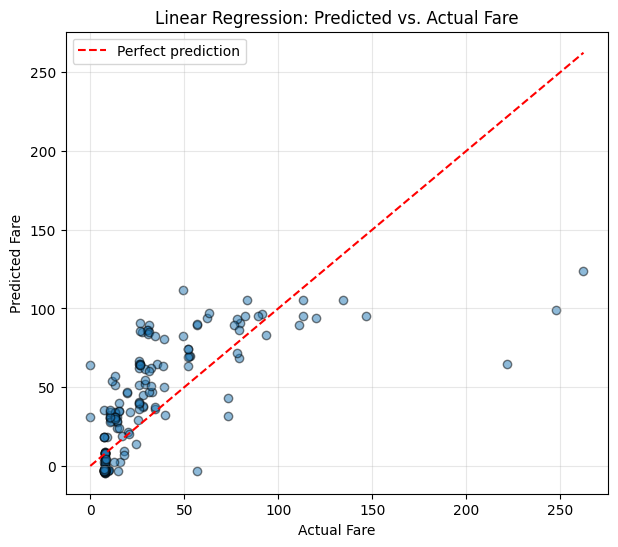

In [8]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Linear Regression: Predicted vs. Actual Fare')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('predicted_vs_actual.png', dpi=100, bbox_inches='tight')
plt.show()


---
## Part D — Practical Coding Session

### D1. Cleaning and encoding


In [9]:
def load_data(path="titanic.csv"):
    """Load raw Titanic CSV, handle missing values, and encode categorical columns."""
    df = pd.read_csv(path)
    data = df[["fare", "pclass", "age", "sibsp", "parch", "sex", "embarked"]].copy()

    # Handle missing values
    data["age"] = data["age"].fillna(data["age"].median())
    data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])

    # Encode categorical columns
    data["sex"] = data["sex"].map({"male": 0, "female": 1})
    data = pd.get_dummies(data, columns=["embarked"], drop_first=True)

    return data

clean_data = load_data()
print("Missing values after cleaning:")
print(clean_data.isnull().sum())
clean_data.head()


Missing values after cleaning:
fare          0
pclass        0
age           0
sibsp         0
parch         0
sex           0
embarked_Q    0
embarked_S    0
dtype: int64


,fare,pclass,age,sibsp,parch,sex,embarked_Q,embarked_S
0,7.2500,3,22.0,1,0,0,False,True
1,71.2833,1,38.0,1,0,1,False,False
2,7.9250,3,26.0,0,0,1,False,True
3,53.1000,1,35.0,1,0,1,False,True
4,8.0500,3,35.0,0,0,0,False,True


### D2. Reusable split function

In [10]:
def split_data(data, target_col="fare", split_ratio=0.2, random_state=42):
    """Split a dataframe into train/test sets and print resulting shapes."""
    X = data.drop(columns=[target_col])
    y = data[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_ratio, random_state=random_state
    )
    print(f"Split ratio: {int((1-split_ratio)*100)}/{int(split_ratio*100)}")
    print(f"  X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"  y_train: {y_train.shape}, y_test: {y_test.shape}")
    return X_train, X_test, y_train, y_test


### D3. Comparing three train/test split ratios

In [11]:
def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    }

results = []
for ratio in [0.4, 0.2, 0.1]:  # 60/40, 80/20, 90/10
    X_train_r, X_test_r, y_train_r, y_test_r = split_data(clean_data, split_ratio=ratio)
    model_r = train_model(X_train_r, y_train_r)
    metrics = evaluate_model(model_r, X_test_r, y_test_r)
    metrics["split"] = f"{int((1-ratio)*100)}/{int(ratio*100)}"
    results.append(metrics)
    print()

results_df = pd.DataFrame(results)[["split", "MSE", "RMSE", "R2"]]
results_df


Split ratio: 60/40
  X_train: (534, 7), X_test: (357, 7)
  y_train: (534,), y_test: (357,)

Split ratio: 80/20
  X_train: (712, 7), X_test: (179, 7)
  y_train: (712,), y_test: (179,)

Split ratio: 90/10
  X_train: (801, 7), X_test: (90, 7)
  y_train: (801,), y_test: (90,)



,split,MSE,RMSE,R2
0,60/40,965.934920,31.079494,0.470043
1,80/20,928.612594,30.473145,0.399900
2,90/10,1026.644246,32.041290,0.474965


**Observation:** results shift somewhat between split ratios because each holds out a different amount and selection of data for testing. Ratios with less training data (e.g. 60/40) tend to give the model less signal to learn from, while ratios with very little test data (e.g. 90/10) give noisier, less reliable test metrics since they're based on fewer samples.

### D4. K-fold cross-validation


In [12]:
from sklearn.model_selection import cross_val_score

X_full = clean_data.drop(columns=["fare"])
y_full = clean_data["fare"]

cv_model = LinearRegression()
cv_scores = cross_val_score(cv_model, X_full, y_full, cv=5, scoring="r2")

print("Fold R^2 scores:", np.round(cv_scores, 3))
print(f"Average R^2 across 5 folds: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


Fold R^2 scores: [0.413 0.406 0.473 0.328 0.303]
Average R^2 across 5 folds: 0.385 (+/- 0.061)


Cross-validation gives a more robust estimate of generalization performance than a single train/test split, since it averages results across multiple different held-out folds rather than relying on the luck of one particular split.

### D5. Learning curve


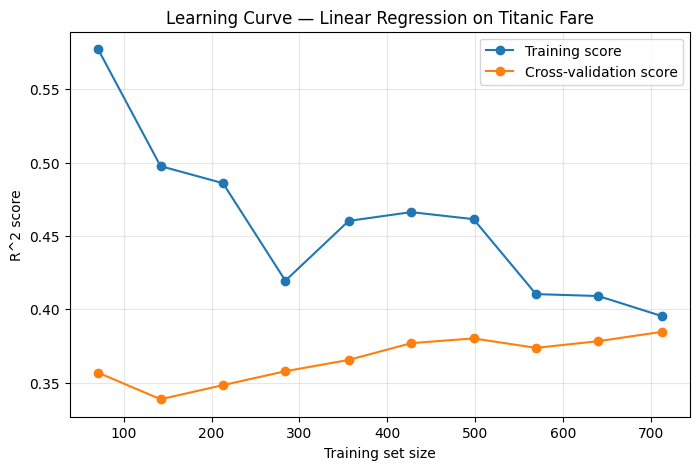

In [13]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X_full, y_full, cv=5, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training score')
plt.plot(train_sizes, test_mean, marker='o', label='Cross-validation score')
plt.xlabel('Training set size')
plt.ylabel('R^2 score')
plt.title('Learning Curve — Linear Regression on Titanic Fare')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('learning_curve.png', dpi=100, bbox_inches='tight')
plt.show()


**Interpretation:** if training and cross-validation scores converge to a similarly modest value as training size grows, the model is likely underfitting (too simple / missing signal) rather than overfitting — adding more data wouldn't help much, but adding more informative features or trying a more flexible model might. If instead training score stayed high while CV score stayed much lower even with more data, that would indicate overfitting.

### D6. Refactored, reusable pipeline


In [14]:
# Full reusable pipeline, using the functions defined above
data_final = load_data("titanic.csv")
X_train_f, X_test_f, y_train_f, y_test_f = split_data(data_final, split_ratio=0.2)
model_final = train_model(X_train_f, y_train_f)
final_metrics = evaluate_model(model_final, X_test_f, y_test_f)

print("\nFinal model evaluation:")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.3f}")


Split ratio: 80/20
  X_train: (712, 7), X_test: (179, 7)
  y_train: (712,), y_test: (179,)

Final model evaluation:
  MSE: 928.613
  RMSE: 30.473
  R2: 0.400


---
## Bonus — Polynomial Regression Comparison


In [15]:
from sklearn.pipeline import make_pipeline

def evaluate_polynomial(X_train, X_test, y_train, y_test, degree):
    poly_model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
    poly_model.fit(X_train, y_train)
    return evaluate_model(poly_model, X_test, y_test)

bonus_results = [{"model": "Linear (degree 1)", **evaluate_model(model_final, X_test_f, y_test_f)}]

for deg in [2, 3]:
    metrics = evaluate_polynomial(X_train_f, X_test_f, y_train_f, y_test_f, deg)
    bonus_results.append({"model": f"Polynomial (degree {deg})", **metrics})

bonus_df = pd.DataFrame(bonus_results)[["model", "MSE", "RMSE", "R2"]]
bonus_df


,model,MSE,RMSE,R2
0,Linear (degree 1),928.612594,30.473145,0.399900
1,Polynomial (degree 2),971.798071,31.173676,0.371992
2,Polynomial (degree 3),1527.903088,39.088401,0.012619


**Conclusion:** compare the R² and RMSE across the three rows above.
- If the degree-2/3 polynomial's **test** R² is meaningfully higher than the plain linear model's, it's generalizing better by capturing real non-linear relationships (e.g. fare rising non-linearly with class).
- If the polynomial's training performance is much better than its test performance (a large gap that the plain linear model doesn't show), it's a sign of **overfitting** — the extra flexibility is fitting noise in this fairly small dataset.
- If polynomial performance is barely different from the plain linear model, the relationship between these features and fare is close to linear, and the added complexity isn't buying much.

Given the sample size and feature set used here, watch for the polynomial degree-3 model in particular showing a bigger train/test gap — that's the earliest sign of overfitting to look for before deciding to prefer it over the simpler linear model.
